# Oefenmodel dwarsdoorsnede ARK 

Dit oefenmodel dient om mechanismen van wellen op regionale schaal
uit te proberen, met name het dichtdrukken van wellen door
uitzetting van de grond in de zomer en de invloed van viscositeit.

loading mfpath.py
NOTEBOOK_NAME = 'experiment_xsec_ARK.ipynb'
Project directory namespace:
rws                  /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/
home                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src
images               /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../images
data                 /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../data


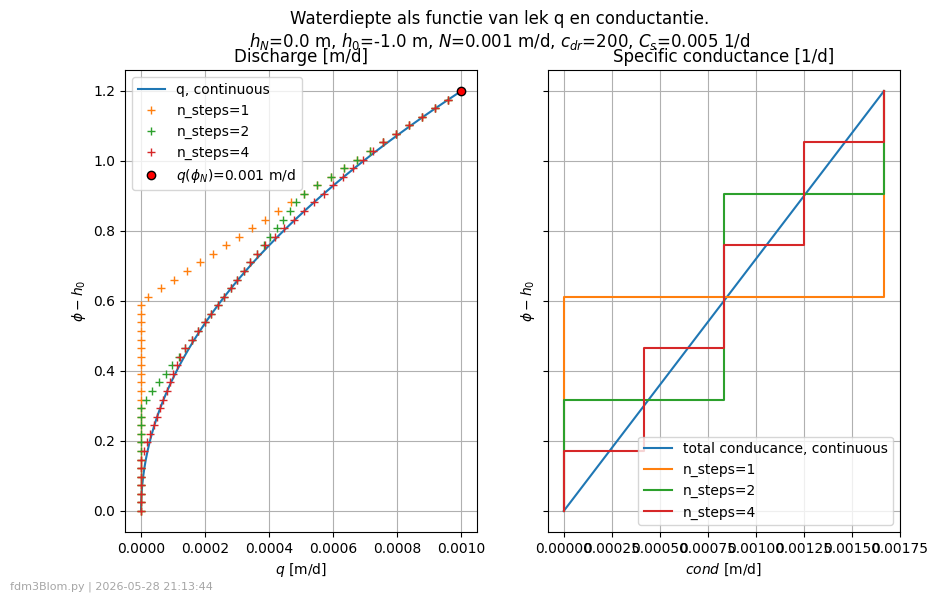

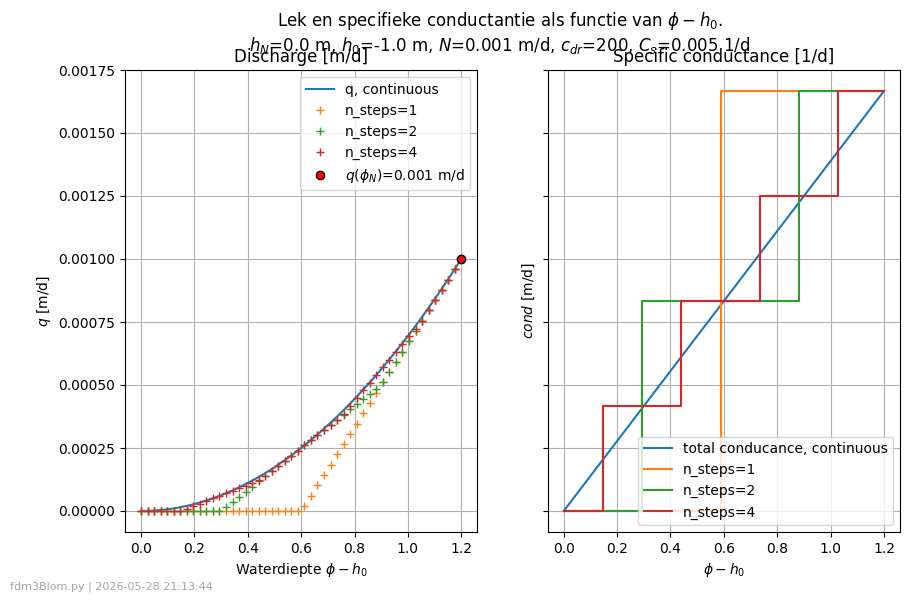

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.interpolate import Akima1DInterpolator
from PIL import Image
from tools.fdm.src import fdm3Blom, mfgrid
from tools.etc import logo, descr, pickleto, picklefrom

NOTEBOOK_NAME = "experiment_xsec_ARK.ipynb"
print(f"NOTEBOOK_NAME = '{NOTEBOOK_NAME}'")

# --- project directory namespace
class Dirs:
    def __init__(self):
        self.rws = "/Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/"
        self.home = os.path.join(self.rws, "src")
        self.images = os.path.join(self.home, '../images')
        self.data = os.path.join(self.home, '../data')
        
dirs = Dirs()

# --- dtypes for boundary conditions of Fdm3
dtypes = fdm3Blom.Fdm3.dtypes

print("Project directory namespace:")
descr(dirs)

## The wellen image (cutout of fig 3.1 in Beemster et all)

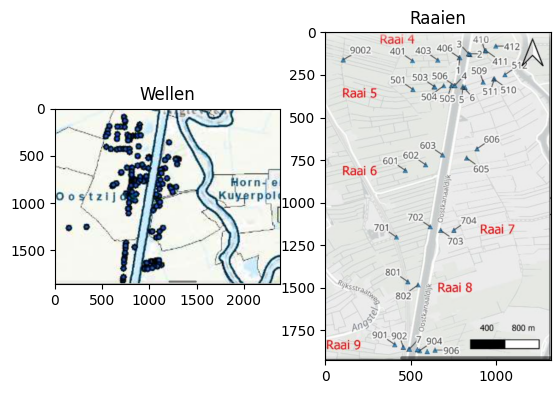

In [2]:
image_wellen = os.path.join(dirs.images,
        "wellen_Beemster_22_fig3_1_128499_131432_473951_476274.png")
image_raaien = os.path.join(dirs.images,
        "raaien_fig2_1_systeemanalyse_Deltares_128127_130749_471773_475601.png")

for image in [image_wellen, image_raaien]:
    assert os.path.isfile(image), f"FileNotFound {image}"

fig, (ax1, ax2) = plt.subplots(1,2)

img_wellen = Image.open(image_wellen)
img_raaien = Image.open(image_raaien)
ax1.imshow(img_wellen)
ax2.imshow(img_raaien)
ax1.set_title("Wellen")
ax2.set_title("Raaien")

plt.show()

In [3]:
from pyproj import Transformer

# --- transformer from WGS84 -> RD New
transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:28992",
    always_xy=True
)

# === Geolocating cut-out of fig 3.1 in Beemster (2022)
# --- NW SE (UL, LR) of image
lonlat = np.array([[4.998927,  52.273840],
                   [5.042055,  52.253094]]
)

print("image_wellen extent")
for lon, lat in lonlat:
    x, y = transformer.transform(lon, lat)
    print(np.round(x), np.round(y))
print()


image_wellen extent
128499.0 476274.0
131432.0 473951.0



In [4]:
wellen = picklefrom(os.path.join(dirs.data, 'wellen.pkl'))
raaien = picklefrom(os.path.join(dirs.data, 'raaien.pkl'))

Loaded <function basename at 0x1062df9c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../data/wellen.pkl
Loaded <function basename at 0x1062df9c0> <-- /Users/Theo/Development/python/mf6_tools/mf6lab/Projects/ARK_RWS/src/../data/raaien.pkl


## ARK bottom profile

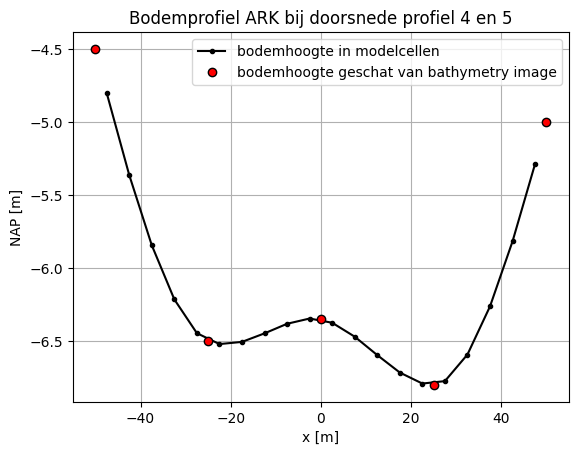

In [5]:
# --- Points estimated from ARK bathymetry image
xark = np.array([-50., -25.,    0.,  25., 50.])
zark = np.array([-4.5, -6.5, -6.35, -6.8, -5.])

# --- Interpolate to get bathymetry profile
interp = Akima1DInterpolator(xark, zark, method='akima', extrapolate=None)

x = np.linspace(-50, 50, 21)
xm = 0.5 * (x[:-1] + x[1:])
zm = interp(xm)

# --- Show profile
fig, ax = plt.subplots()
ax.plot(xm, zm, 'k.-', label='bodemhoogte in modelcellen')
ax.plot(xark, zark, 'ro', mec='k', label='bodemhoogte geschat van bathymetry image')
ax.grid()
ax.set_title("Bodemprofiel ARK bij doorsnede profiel 4 en 5")
ax.set_xlabel('x [m]')
ax.set_ylabel('NAP [m]')
ax.legend()

xm_ark, zm_ark = xm, zm


# The finite difference model

In [132]:
# --- Basic size and model grid properties
L, b, ddamw, Dx_grid, Dx_sloot = 2500., 50., 1, 5., 25.

# --- Zone properties
class Zone():
    def __init__(self, name:str, x: tuple, z: tuple, k: tuple, rhow: float, zorder: float=1, fc: str=None):
        self.name = name
        self.x = x
        self.z = z
        self.k = k
        self.rhow = rhow # 2.6 * 0.65 + 1 * 0.35 # --- (Assume sane with 35% porostiy)
        self.fc = fc
        self.zorder = zorder
            
    @property
    def D(self):        
        return abs(self.z[1] - self.z[0])
    @property
    def ka(self):
        return np.sqrt(self.k[0] * self.k[1])
    @property
    def w(self):
        raise NotImplementedError("w not implemented")
        
    def patch(self, fc=None, ec='none', zorder=1):
        if fc is None:
            fc = self.fc
        if zorder is None:
            zorder = self.zorder
        LL = (self.x[0], self.z[1])
        width = abs(self.x[1] - self.x[0])
        height = abs(self.z[0] - self.z[1])
        return Rectangle(LL, width, height, fc=fc, ec=ec, zorder=zorder)
        
# --- Natte dichtheid lagen (Beemster e.a. 02022 Tabel B6.4)
dichtheid = {'EC': {'name': 'Echteld', 'rhow': 1.4},
             'HV': {'name': 'Naaldwijk HV', 'rhow': 1.05}, # in BBO n HGP 0.98
             'WK': {'name': 'Naaldwijk Wormer klei', 'rhow': 1.4},
             'BV': {'name': 'Naaldwijk Basisveen', 'rhow': 1.1}
}

# --- The canal itself
ARK = Zone('ARK', x=[-b, b], z=[-0.4, -6.7], k=[1000., 1000.], rhow=1., zorder=2, fc='blue')
ARK.heart_line = np.array([[129810.0, 475695.0], [129006.0, 471010.0]])
ARK.bot_elev = np.array([(x_, z_) for x_, z_ in zip(xm_ark, zm_ark)]).round(2)
ARK.c = 10.
ARK.yRD = 474200.

canal_bot = Zone('canal_bot', x=[-b, b], z=[-6.5, -6.7], k=[1000., 1000.], rhow=1.0, fc='gray')
canal_bot.c = 10

# --- Polder levels
polW = {'pp':-2.4}
polE = {'pp':-1.9}

# --- Sheet piling
damW   = Zone('damwand_west', x=[-b-ddamw, -b], z=[0, -12.], k=[1e-6, 1e-6], rhow=7, fc='black')         
damE   = Zone('damwand_east', x=[ b,  b+ddamw], z=[0, -12.], k=[1e-6, 1e-6], rhow=7, fc='black')

# --- Cover layer
dekW  = Zone('deklaag west', x=[-L, 0], z=[-1.9, -5.8], k=[1.0, 0.003], rhow=dichtheid['BV']['rhow'], zorder=2, fc='brown')
dekE  = Zone('deklaag oost', x=[ 0, L], z=[-1.8, -5.0], k=[1.0, 0.003], rhow=dichtheid['BV']['rhow'], zorder=2, fc='brown')

# --- Boxtel Formation
boxW    = Zone('boxtel west', x=[-L, 0], z=[-5.8, -10.], k=[2., 2/3.], rhow=2.6 * 0.6 + 1 * 0.4, fc='gold')
boxE    = Zone('boxtel oost', x=[ 0, L], z=[-5.0, -10.], k=[2., 2/3.], rhow=2.6 * 0.6 + 1 * 0.4, fc='gold')

# --- Sterksel Formation
strk    = Zone('sterksel', x=[-L, L], z=[ -10., -50.], k=[50., 6.], rhow=2.6 * 0.65 + 1 * 0.35, fc='yellow')

# --- Peize-Waalre
peize    = Zone('sterksel', x=[-L, L], z=[ -50., 150], k=[35., 7.], rhow=2.6 * 0.65 + 1 * 0.35, fc='khaki')

# --- Ditches
dekW.sloten = {'x': np.arange(-b - Dx_grid / 2, -L, -Dx_sloot), 'b':2, 'd':1, 'h':polW['pp']}
dekE.sloten = {'x': np.arange(+b + Dx_grid / 2, +L, +Dx_sloot), 'b':2, 'd':1, 'h':polE['pp']}

for dek in [dekW, dekE]:
    dek.sloten['bot'] = dek.sloten['h'] - dek.sloten['d']
    dek.sloten['z'] = (dek.sloten['h'] - 0.5 * dek.sloten['d']) * np.ones(len(dek.sloten['x']))
    dek.sloten['omega'] = 0.5 * dek.sloten['b'] * np.pi / 2
    dek.sloten['w'] = 1 / (np.pi * dek.ka) * np.log(dek.D / dek.sloten['omega'] * dek.k[0] / dek.k[1])

# --- Boils (check h and w @@@)
for box, dek in zip([boxW, boxE], [dekW, dekE]):
    box.wellen = {'x': dek.sloten['x'], 'z':(box.z[0] - 0.1) * np.ones(len(dek.sloten['x'])),
                  'h': dek.sloten['h'] + 0.5, 'w': 1.}
    

## Model network

In [41]:
# --- Increasing model layer thickness in the Sterksel layer
Dstrk = strk.z[0] - strk.z[-1]
zstrk = np.round(strk.z[0] - np.logspace(0, np.log10(Dstrk), 10), 1)
zstrk

array([-11. , -11.5, -12.3, -13.4, -15.2, -17.8, -21.7, -27.6, -36.5,
       -50. ])

In [42]:
# --- Use 5 m  grid horizontally
x = np.hstack((np.linspace(-L, L, int(2 * L / Dx_grid) + 1), np.array(damW.x), np.array(damE.x)))

# --- Get useful layer elevations
z = []
for zone in [ARK, dekW, dekE, boxW, boxE]:
    z.append(zone.z[0])
    z.append(zone.z[1])
z = np.unique(np.hstack((np.array(z), np.linspace(-2.5, -12, 20), zstrk)))[::-1]
z = np.unique(z)[::-1]

gr = mfgrid.Grid(x, None, z)
print(f'gr.shape = {gr.shape}')

z


gr.shape = (32, 1, 1002)


array([ -0.4,  -1.8,  -1.9,  -2.5,  -3. ,  -3.5,  -4. ,  -4.5,  -5. ,
        -5.5,  -5.8,  -6. ,  -6.5,  -6.7,  -7. ,  -7.5,  -8. ,  -8.5,
        -9. ,  -9.5, -10. , -10.5, -11. , -11.5, -12. , -12.3, -13.4,
       -15.2, -17.8, -21.7, -27.6, -36.5, -50. ])

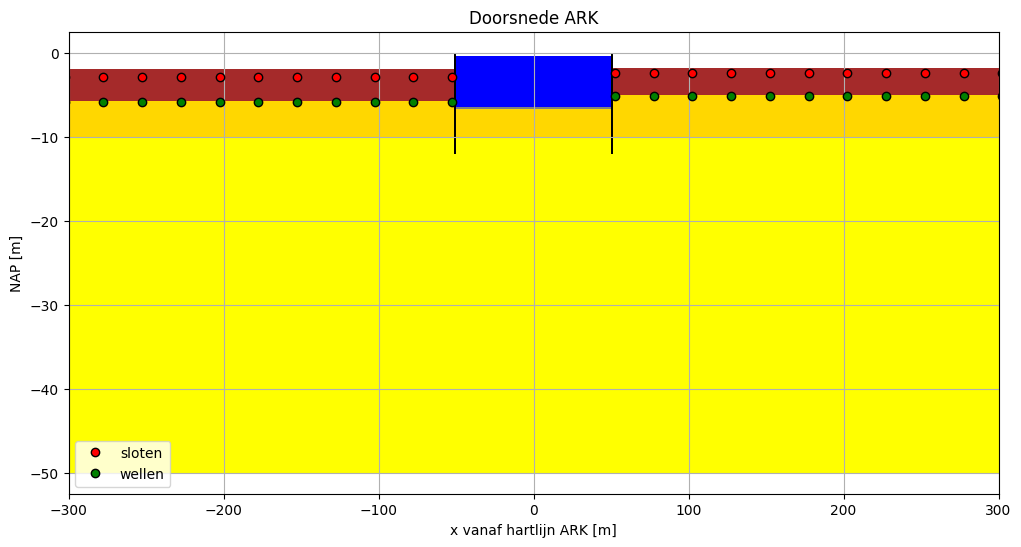

In [109]:
# --- Show the grid:

fig, ax = plt.subplots(figsize=(12, 6))

def plot_xsec(ax):
    for zone in [strk, boxW, boxE, dekW, dekE, damW, damE, ARK, canal_bot]:
        ax.add_patch(zone.patch())
    ax.plot(dekW.sloten['x'], dekW.sloten['z'], 'ro', mec='k', label='sloten')
    ax.plot(dekE.sloten['x'], dekE.sloten['z'], 'ro', mec='k', label='')
    ax.plot(boxW.wellen['x'], boxW.wellen['z'], 'go', mec='k', label='wellen')
    ax.plot(boxE.wellen['x'], boxE.wellen['z'], 'go', mec='k', label='')

plot_xsec(ax)
    
ax.set_title("Doorsnede ARK")
ax.set_xlabel("x vanaf hartlijn ARK [m]")
ax.set_ylabel("NAP [m]")
ax.grid()
ax.set_xlim(-300, 300)
ax.legend()


In [44]:
N=10

print('\nx_sloten:')
for dek, name in zip([dekW, dekE], ['deklaag west', 'deklaag oost']):
    print(name)
    print('x :', dek.sloten['x'])
    print('z :', dek.sloten['z'])
    print('omega: ', dek.sloten['omega'])
    print('w :', dek.sloten['w'])
    print('h :', dek.sloten['h'])

    N = len(dek.sloten['x'])
    xyz = np.vstack((dek.sloten['x'], np.zeros(N), dek.sloten['z'])).T
    dek.sloten['Ig'] = gr.Iglob_from_xyz(xyz)
    print('Ig :', dek.sloten['Ig'])



x_sloten:
deklaag west
x : [  -52.5   -77.5  -102.5  -127.5  -152.5  -177.5  -202.5  -227.5  -252.5
  -277.5  -302.5  -327.5  -352.5  -377.5  -402.5  -427.5  -452.5  -477.5
  -502.5  -527.5  -552.5  -577.5  -602.5  -627.5  -652.5  -677.5  -702.5
  -727.5  -752.5  -777.5  -802.5  -827.5  -852.5  -877.5  -902.5  -927.5
  -952.5  -977.5 -1002.5 -1027.5 -1052.5 -1077.5 -1102.5 -1127.5 -1152.5
 -1177.5 -1202.5 -1227.5 -1252.5 -1277.5 -1302.5 -1327.5 -1352.5 -1377.5
 -1402.5 -1427.5 -1452.5 -1477.5 -1502.5 -1527.5 -1552.5 -1577.5 -1602.5
 -1627.5 -1652.5 -1677.5 -1702.5 -1727.5 -1752.5 -1777.5 -1802.5 -1827.5
 -1852.5 -1877.5 -1902.5 -1927.5 -1952.5 -1977.5 -2002.5 -2027.5 -2052.5
 -2077.5 -2102.5 -2127.5 -2152.5 -2177.5 -2202.5 -2227.5 -2252.5 -2277.5
 -2302.5 -2327.5 -2352.5 -2377.5 -2402.5 -2427.5 -2452.5 -2477.5]
z : [-2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9
 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9
 -2.9 -2.9 -2.9 -2.9 -2.9 -2.9

In [133]:
gr = mfgrid.Grid(x, None, z)

for zone in [ARK, canal_bot, damW, damE, dekW, dekE, boxW, boxE, strk]:
    zone.mask = ((gr.ZM <= zone.z[0]) &
                 (gr.ZM >= zone.z[1]) &
                 (gr.XM >= zone.x[0]) &
                 (gr.XM <= zone.x[1])                    
    )

# --- Prevent overlap with damw and ARK
for zone in [dekW, dekE, boxW, boxE, strk]:
    zone.mask = zone.mask & ~damW.mask & ~damE.mask & ~ARK.mask



# --- Attribute properties to masked zones
kh = gr.const(0.)
kv = gr.const(0.)
for zone in [dekW, dekE, boxW, boxE, strk, ARK, damE, damW]:
    kh[zone.mask] = zone.k[0]
    kv[zone.mask] = zone.k[1]
    
mask = canal_bot.mask
kv[mask] = 0.5 * gr.DZ[mask] / canal_bot.c

# --- IBOUND ----
IBOUND = gr.const(1, dtype=int)
IBOUND[ARK.mask] = -1
IBOUND[damW.mask] = 0
IBOUND[damE.mask] = 0

# IBOUND[:, 0, [0, -1]] = -1

IBOUND[np.logical_and(gr.ZM > dekW.z[0], gr.XM < -b)] = 0
IBOUND[np.logical_and(gr.ZM > dekE.z[0], gr.XM >  b)] = 0

nW, nE = len(dekW.sloten['x']), len(dekE.sloten['x'])
GHB_W = np.zeros(nW, dtype=dtypes['ghb']) # dtype([('Ig', '<i8'), ('h', '<f8'), ('C', '<f8')])
GHB_E = np.zeros(nE, dtype=dtypes['ghb']) # dtype([('Ig', '<i8'), ('h', '<f8'), ('C', '<f8')])
DRN_W = np.zeros(nW, dtype=dtypes['drn']) # dtype([('Ig', '<i8'), ('h', '<f8'), ('C', '<f8')])
DRN_E = np.zeros(nE, dtype=dtypes['drn']) # dtype([('Ig', '<i8'), ('h', '<f8'), ('C', '<f8')])
for GHB, DRN, dek, box in zip([GHB_W, GHB_E], [DRN_W, DRN_E], [dekW, dekE], [boxW, boxE]):
    n = len(GHB)
    xyz = np.vstack((dek.sloten['x'], np.zeros(n), dek.sloten['z'])).T
    GHB['Ig'] = gr.Iglob_from_xyz(xyz)
    GHB['h']  = dek.sloten['h']
    GHB['C']   = 1 / dek.sloten['w']
    
    xyz = np.vstack((box.wellen['x'], np.zeros(n), box.wellen['z'])).T
    DRN['Ig'][:] = gr.Iglob_from_xyz(xyz)
    DRN['h'] = box.wellen['h']
    DRN['C'] = 1 / box.wellen['w']
    
ghb = np.concatenate((GHB_W, GHB_E))
drn = np.concatenate((DRN_W, DRN_E))


HI = gr.const(0.)
HI[gr.XM < 0] = dekW.sloten['h']
HI[gr.XM >=0] = dekE.sloten['h']
HI[ARK.mask] = ARK.z[0]

Ss = gr.const(0.0001)

FQ = gr.const(0.)

mdl = fdm3Blom.Fdm3(gr=gr, K=(kh, kh, kv), c=None, S=Ss, IBOUND=IBOUND, HI=HI, FQ=FQ)

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:234: RuntimeWarning: divide by zero encountered in divide
  Rx2 = 0.5 * dx / (dy * dz) / kx
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:235: RuntimeWarning: divide by zero encountered in divide
  Rx1 = 0.5 * dx / (dy * dz) / kx
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:236: RuntimeWarning: divide by zero encountered in divide
  Ry  = 0.5 * dy / (dz * dx) / ky
/Users/Theo/Development/python/hydro_tools/tools/fdm/src/fdm3Blom.py:237: RuntimeWarning: divide by zero encountered in divide
  Rz  = 0.5 * dz / (dx * dy) / kz


In [193]:
out = mdl.simulate(DRN=drn, GHB=ghb, tm=[1, 1.5], verbose=False)

gr.dphi = 0.1 
gr.dpsi = 0.25

out['gr'] = gr
out['psi'] = gr.psi_row(out['Qx'])

# --- phi and psi levels for contourin heads and stream lines    
phi_levels = np.arange(np.floor(polW['pp']), np.ceil(ARK.z[0]), gr.dphi)
psi_levels = np.arange(np.floor(out['psi'].min()), np.ceil(out['psi'].max()), gr.dpsi)


Non-linear options: ['DRN'], starting outer iterations:
iouter =    0, err =     1.1639 m, errBalance =     3.9055
iouter =    1, err =    0.15541 m, errBalance =     2.3276
iouter =    2, err =    0.10723 m, errBalance =     1.6885
iouter =    3, err =   0.082753 m, errBalance =     1.1942
iouter =    4, err =    0.04869 m, errBalance =    0.68993
iouter =    5, err =   0.025528 m, errBalance =    0.31716
iouter =    6, err =  0.0099619 m, errBalance =    0.11433
iouter =    7, err =  0.0028761 m, errBalance =   0.032202
iouter =    8, err = 0.00061416 m, errBalance =  0.0070559
iouter =    9, err = 9.8728e-05 m, errBalance =  0.0012436
iouter =   10, err = 1.2538e-05 m, errBalance = 0.00018686
iouter =   11, err = 1.8858e-06 m, errBalance = 2.6976e-05
iouter =   12, err = 3.5141e-07 m, errBalance = 3.9071e-06
iouter =   13, err = 6.6067e-08 m, errBalance = 6.2578e-07
Converged, normal termination.

===== Water balance of the entire model =====
Model grid = (32, 1, 1002)

Sum over all

/Users/Theo/Development/python/hydro_tools/tools/fdm/src/mfgrid.py:2020: UserWarning: This only works when all flow is within plane zx given by row
  warnings.warn("This only works when all flow is within plane zx given by row")


## Show the cross section

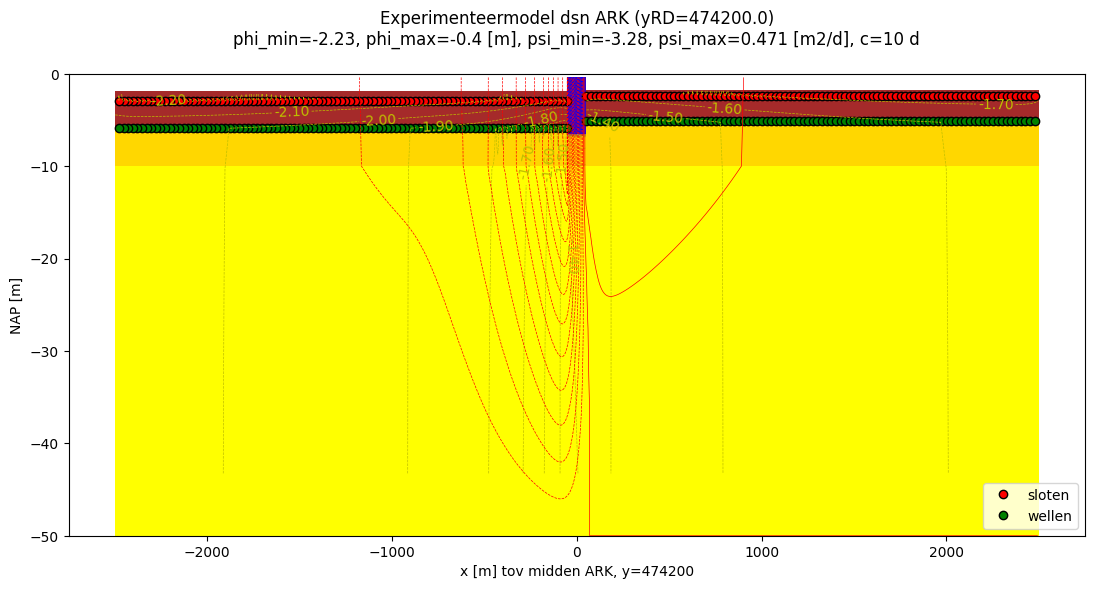

In [194]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_xsec(ax)

psi = gr.psi_row(out['Qx'])

phi_min, phi_max = np.floor(np.nanmin(out['Phi']) * 100)/100, np.ceil(np.nanmax(out['Phi']) * 100)/100 
psi_min, psi_max = np.round(psi.min(),3), np.round(psi.max(), 3)

cs_phi = ax.contour(gr.xm, gr.zm, out['Phi'][:, 0, :], colors='y', linewidths=0.5, levels=phi_levels)
cs_psi = ax.contour(gr.x[1:-1], gr.z, psi, colors='r', linewidths=0.5, levels=psi_levels)

ax.set_title(f"Experimenteermodel dsn ARK (yRD={ARK.yRD})" + "\n" +
      f"phi_min={phi_min}, phi_max={phi_max} [m], psi_min={psi_min}, psi_max={psi_max} [m2/d], c={canal_bot.c} d" +
      "\n"      
)

ax.clabel(cs_phi, levels=cs_phi.levels, fontsize=10, fmt='%.2f')

ax.set_aspect(50)
#ax.set_xlim(-300, 300)
ax.set_ylim(-50, 0)
ax.legend(loc='lower right')

ax.set_xlabel('x [m] tov midden ARK, y=474200')
ax.set_ylabel('NAP [m]')
plt.show()
plt.close('all')


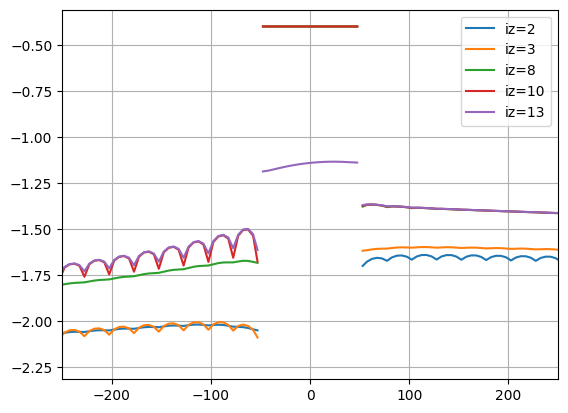

In [195]:
fig, ax = plt.subplots()
for iz in [2, 3, 8, 10, 13]: # range(gr.nz):
    ax.plot(gr.xm, out['Phi'][iz, 0, :], label=f"iz={iz}")
    ax.set_xlim(-250, 250)
ax.grid()
ax.legend()

In [186]:
np.round(out['Q'].ravel()[ghb['Ig']], 3), np.round(out['Q'].ravel()[drn['Ig']], 3)
np.round(out['Phi'].ravel()[ghb['Ig']], 3), np.round(out['Phi'].ravel()[drn['Ig']], 3)

dPhi = out['Phi'].ravel()[drn['Ig']] - out['Phi'].ravel()[ghb['Ig']]
dPhi / -(out['Q'].ravel()[ghb['Ig']] / Dx_sloot)


array([1635.44829302, 1325.78193304, 1243.94999907, 1208.73340483,
       1192.39314686, 1184.61888002, 1180.87776898, 1179.0675751 ,
       1178.18927373, 1177.76250266, 1177.55495691, 1177.45396776,
       1177.404807  , 1177.38086733, 1177.36920563, 1177.36352308,
       1177.36075319, 1177.35940262, 1177.35874388, 1177.35842248,
       1177.35826562, 1177.35818904, 1177.35815164, 1177.35813337,
       1177.35812444, 1177.35812007, 1177.35811794, 1177.35811689,
       1177.35811638, 1177.35811613, 1177.35811601, 1177.35811595,
       1177.35811592, 1177.3581159 , 1177.3581159 , 1177.35811589,
       1177.35811589, 1177.35811589, 1177.35811589, 1177.35811589,
       1177.35811589, 1177.35811589, 1177.35811589, 1177.35811589,
       1177.35811589, 1177.35811589, 1177.35811589, 1177.35811589,
       1177.35811589, 1177.35811589, 1177.35811589, 1177.35811589,
       1177.35811589, 1177.35811589, 1177.35811589, 1177.35811589,
       1177.35811589, 1177.35811589, 1177.35811589, 1177.35811

In [191]:
print(f"C deklaag : {np.median(dPhi) / (-np.median(out['Q'].ravel()[ghb['Ig']]) / Dx_sloot):.0f} d")

C deklaag : 1160 d


In [192]:
DRN

array([(8528, -1.4, 1.), (8533, -1.4, 1.), (8538, -1.4, 1.),
       (8543, -1.4, 1.), (8548, -1.4, 1.), (8553, -1.4, 1.),
       (8558, -1.4, 1.), (8563, -1.4, 1.), (8568, -1.4, 1.),
       (8573, -1.4, 1.), (8578, -1.4, 1.), (8583, -1.4, 1.),
       (8588, -1.4, 1.), (8593, -1.4, 1.), (8598, -1.4, 1.),
       (8603, -1.4, 1.), (8608, -1.4, 1.), (8613, -1.4, 1.),
       (8618, -1.4, 1.), (8623, -1.4, 1.), (8628, -1.4, 1.),
       (8633, -1.4, 1.), (8638, -1.4, 1.), (8643, -1.4, 1.),
       (8648, -1.4, 1.), (8653, -1.4, 1.), (8658, -1.4, 1.),
       (8663, -1.4, 1.), (8668, -1.4, 1.), (8673, -1.4, 1.),
       (8678, -1.4, 1.), (8683, -1.4, 1.), (8688, -1.4, 1.),
       (8693, -1.4, 1.), (8698, -1.4, 1.), (8703, -1.4, 1.),
       (8708, -1.4, 1.), (8713, -1.4, 1.), (8718, -1.4, 1.),
       (8723, -1.4, 1.), (8728, -1.4, 1.), (8733, -1.4, 1.),
       (8738, -1.4, 1.), (8743, -1.4, 1.), (8748, -1.4, 1.),
       (8753, -1.4, 1.), (8758, -1.4, 1.), (8763, -1.4, 1.),
       (8768, -1.4, 1.),

In [123]:
GHB

array([(2516, -1.9, 0.02638855), (2521, -1.9, 0.02638855),
       (2526, -1.9, 0.02638855), (2531, -1.9, 0.02638855),
       (2536, -1.9, 0.02638855), (2541, -1.9, 0.02638855),
       (2546, -1.9, 0.02638855), (2551, -1.9, 0.02638855),
       (2556, -1.9, 0.02638855), (2561, -1.9, 0.02638855),
       (2566, -1.9, 0.02638855), (2571, -1.9, 0.02638855),
       (2576, -1.9, 0.02638855), (2581, -1.9, 0.02638855),
       (2586, -1.9, 0.02638855), (2591, -1.9, 0.02638855),
       (2596, -1.9, 0.02638855), (2601, -1.9, 0.02638855),
       (2606, -1.9, 0.02638855), (2611, -1.9, 0.02638855),
       (2616, -1.9, 0.02638855), (2621, -1.9, 0.02638855),
       (2626, -1.9, 0.02638855), (2631, -1.9, 0.02638855),
       (2636, -1.9, 0.02638855), (2641, -1.9, 0.02638855),
       (2646, -1.9, 0.02638855), (2651, -1.9, 0.02638855),
       (2656, -1.9, 0.02638855), (2661, -1.9, 0.02638855),
       (2666, -1.9, 0.02638855), (2671, -1.9, 0.02638855),
       (2676, -1.9, 0.02638855), (2681, -1.9, 0.02638855

In [127]:
dekW.sloten['h'], boxW.wellen['h'], GHB['h']


(-2.4,
 -1.9,
 array([-1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9,
        -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9, -1.9]))